## Importing the Libraries
NumPy is used for numerical computation.

Matplotlib is used for data visualization.

TensorFlow provides access to the CIFAR-10 dataset.

Scikit-learn is used for splitting the dataset into training and validation sets.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

## Loading the CIFAR-10 Dataset
In this section, we laod the CIFAR-10 dataset using TensorFlow/Keras.

The dataset is already divided into two parts:

- **Training Set** - Used to teach the neural network.
- **Test Set** - Used to evaluate how well the trained model performs on unseen image.

Each image has a corresponding label that identifies its correct class.
The dataset consists of:
- 50,000 training images
- 10,000 testing images
- 10 object categories
- Image dimensions: 32×32 pixels (RGB)
- Color channels: 3 (Red, Green, Blue)
- Number of classes: 10
  * Airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Image format: Numpy arrays
- Pixel value range: 0-255 (unsigned 8-bit integer)


when we load the dataset, TensorFlow return four variables:
- 'x_train' -> Training images (features)
- 'y_train' -> Training labels
- 'x_test' -> test images (features)
- 'y_test' -> Test labels


Data Source:
https://www.cs.toronto.edu/~kriz/cifar.html

In [20]:
#Load the CIFAR-10 dataset

print("Loading CIFAR-10 Dataset")

#Load the dataset
(x_train,y_train), (x_test,y_test) = cifar10.load_data()

print("\nDataset has been loaded")

print(f"\nTraining images shape: {x_train.shape}")
print(f"Training lables shape: {y_train.shape}")

print(f"\nTesting images shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")


Loading CIFAR-10 Dataset

Dataset has been loaded

Training images shape: (50000, 32, 32, 3)
Training lables shape: (50000, 1)

Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [37]:
# CIFAR-10 class names
class_names = [
   "airplane",
   "automobile",
   "bird",
   "cat",
   "deer",
   "dog",
   "frog",
   "horse",
   "ship",
   "truck"
]

## Exploring the CIFAR-10 Dataset
Before building a neural network, it is important to understand what the dataset looks like.

In this section we will:

- Display some sample images
- Display their numerical labels
- Convert numerical labels into class names
- Undersatnd how computers and humans view the same image differently

This helps verify that a dataset has been loaded successfully before training a model

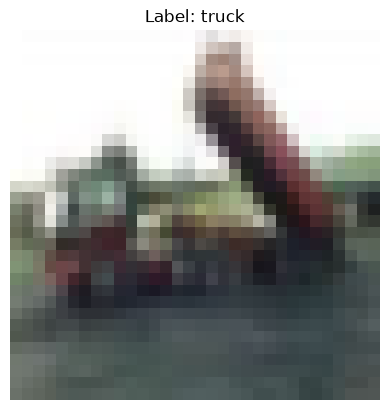

In [38]:
#Display one image
#choose an image
index = 2
plt.imshow(x_train[index])
plt.title(f"Label: {class_names[y_train[index]]}")
plt.axis("off")
plt.show()


In [44]:
#Flatten the label, y_train and y_test to change how the data is organised, instead of [1] we get 1
y_train = y_train.flatten()
y_test = y_test.flatten()

## Exploring the Distribution of classes
Before training any machine learning model, it is important to understand how the data is distributed.
- Does every class contain the same number of samples?
- Is the dataset balanced or imbalanced?

A balanced dataset means every class has approximately the same number of training examples. This is important beacuse a model trained on an imbalnaced dataset may become biased toward classes that appear more frequently.
In this section, we will count the number of images belonging to each class in the CIFAR-10 training dataset and visualise the class distribution using a bar chart.

In [45]:
#Count images in each class
unique_classes, class_counts = np.unique(y_train, return_counts=True)
print("Class Distribution in CIFAR-10")

for i in range(len(unique_classes)):
    print(f"{class_names[unique_classes[i]]: <12}: {class_counts[i]} images")

Class Distribution in CIFAR-10
airplane    : 5000 images
automobile  : 5000 images
bird        : 5000 images
cat         : 5000 images
deer        : 5000 images
dog         : 5000 images
frog        : 5000 images
horse       : 5000 images
ship        : 5000 images
truck       : 5000 images


# Exploratory Data Analysis (EDA): Class Distribution

After counting the number of images in each class, it is helpful to visualize the results.

A bar chart makes it easier to determine whether the dataset is balanced or imbalanced.

Balanced datasets generally allow machine learning models to learn equally from all classes, while imbalanced datasets can introduce bias toward classes with more training examples.

In this section, we create a bar chart showing the number of training images in each CIFAR-10 class.
 

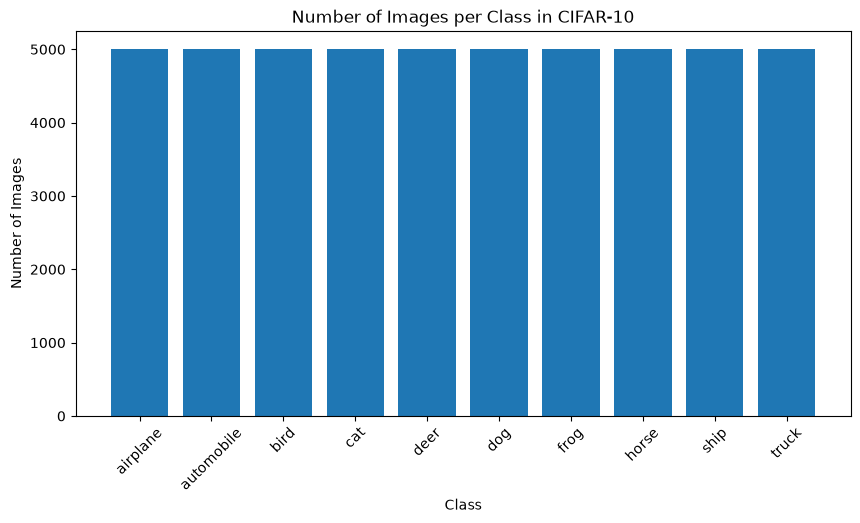

In [46]:
#Visualize the number f images in each class

plt.figure(figsize=(10,5))
plt.bar(class_names, class_counts)
plt.title("Number of Images per Class in CIFAR-10")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

## Exploratory Data Analysis: Pixel Value Distribution
Although humans perceive images as objects, computers represent every image as numerical pixel values.
Before training a neural network, it is useful to understand how these pixel values are distributed.
Since the images have already been normalized, every pixel value should lie between 0 and 1.
Visualizing the pixel distribution helps verify that preprocessing has been performed correctly and provides insight into the characteristics of the dataset.

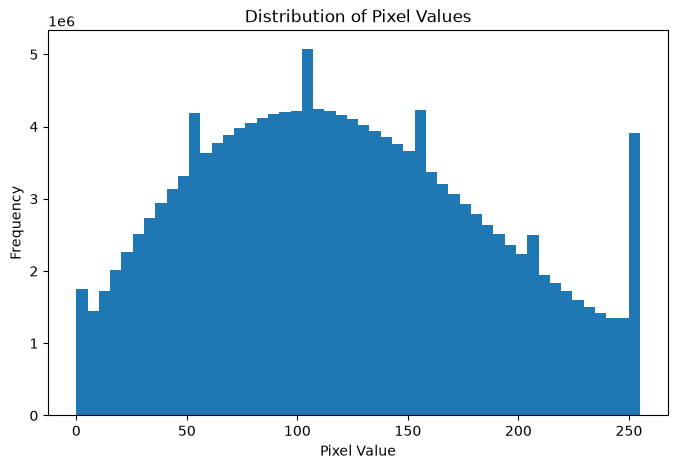

In [47]:
# Display the distribution of pixel values
plt.figure(figsize=(8,5))
plt.hist(x_train.flatten(), bins=50)
plt.title("Distribution of Pixel Values")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()